In [1]:
import requests 
from urllib.parse import urlencode
import urllib3
import matplotlib.pyplot as plt
urllib3.disable_warnings()

In [2]:
lon, lat = 37.61191755, 55.7965029
param={
    'planchers_tot':56, # общее количество этажей
    'height':179.9, # высота обхекта (м)
    'souterrain':2, # количество подземных этажей
    'planchers_sur':54, # количество надземных этажей
    'n_app':450, # количество квартир
    'superficie_tot':38910, # общая площадь объекта 
    'espace_de_vie':22301.0, # жилая площадь объекта
    'lon':lon, # долгота 
    'lat':lat # широта 
}
url = 'http://127.0.0.1:5000/price?'+urlencode(param)
print(url)

r = requests.get(url, verify=False)
if r.status_code!=200:
    print('Failure', r.status_code)
print(r.text)

http://127.0.0.1:5000/price?planchers_tot=56&height=179.9&souterrain=2&planchers_sur=54&n_app=450&superficie_tot=38910&espace_de_vie=22301.0&lon=37.61191755&lat=55.7965029
{
  "code": 0,
  "csv_name": "results/prognose_2025-09-15_08-33-43.csv",
  "dates": [
    "2025-09-01",
    "2025-12-01",
    "2026-03-01",
    "2026-06-01",
    "2026-09-01",
    "2026-12-01",
    "2027-03-01",
    "2027-06-01",
    "2027-09-01"
  ],
  "excel_name": "results/prognose_2025-09-15_08-33-43.xlsx",
  "forecast_horizon": [
    0.0,
    0.25,
    0.5,
    0.75,
    1.0,
    1.25,
    1.5,
    1.75,
    2.0
  ],
  "lat": 55.7965029,
  "lon": 37.61191755,
  "official": [
    1.0,
    1.014,
    1.025,
    1.037,
    1.048,
    1.06,
    1.071,
    1.083,
    1.096
  ],
  "price_index": [
    1.0,
    1.013,
    1.028,
    1.046,
    1.066,
    1.087,
    1.109,
    1.132,
    1.154
  ],
  "pricemetr_dom": [
    446.96,
    452.91,
    459.46,
    467.56,
    476.33,
    485.71,
    495.59,
    505.84,
    51

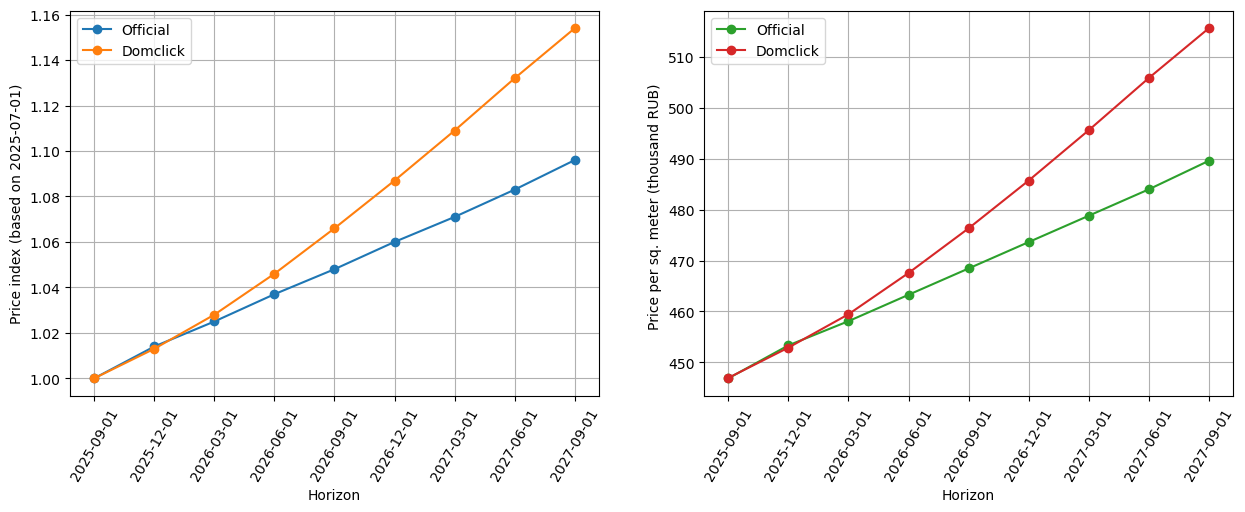

In [3]:
res=eval(r.text)
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(res['forecast_horizon'], res['official'], label='Official', marker='o')
plt.plot(res['forecast_horizon'], res['price_index'], label='Domclick', marker='o')
plt.legend()
plt.grid()
plt.xlabel('Horizon')
plt.ylabel('Price index (based on 2025-07-01)')
plt.xticks(res['forecast_horizon'], res['dates'], rotation=60)

plt.subplot(1,2,2)
plt.plot(res['forecast_horizon'], res['pricemetr_off'], label='Official', marker='o', c='tab:green')
plt.plot(res['forecast_horizon'], res['pricemetr_dom'], label='Domclick', marker='o', c='tab:red')
plt.legend()
plt.grid()
plt.xlabel('Horizon')
plt.ylabel('Price per sq. meter (thousand RUB) ')
plt.xticks(res['forecast_horizon'], res['dates'], rotation=60)

plt.show()

In [4]:
lon, lat = 37.61191755, 55.7965029
param={
    'lon':lon, # долгота 
    'lat':lat, # широта 
    'year':2026, # прогнозируемый год
    'month':12, # прогнозируемый месяц
}
url= 'http://127.0.0.1:5000/demand?'+urlencode(param)
print(url)
r = requests.get(url, verify=False)
if r.status_code!=200:
    print('Failure', r.status_code)
eval(r.text)

http://127.0.0.1:5000/demand?lon=37.61191755&lat=55.7965029&year=2026&month=12


{'1': 0.42,
 '2': 0.35,
 '3': 0.04,
 '4': 0.19,
 'code': 0,
 'date': '2026-12-01',
 'district': 'Марьина Роща',
 'response': 'Okay'}